In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Construct Brillouin Zone

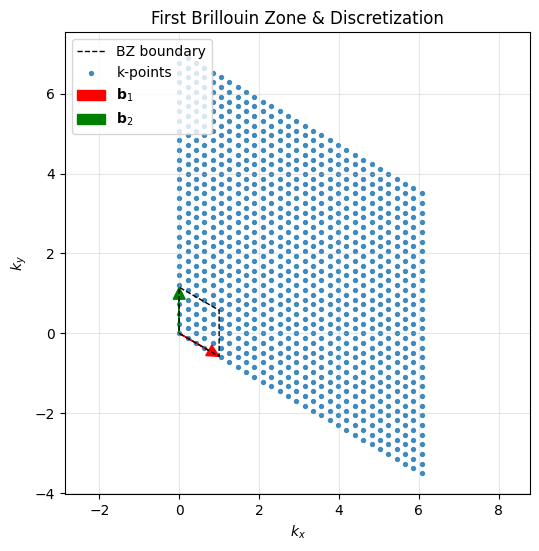

In [23]:
a = 1 # Lattice constant
L1, L2 = 30, 30  # You can adjust these for denser/sparser sampling

# Define reciprocal lattice vectors
a1,a2 = a* np.array([1,0]),a* np.array([np.cos(np.pi/3),np.sin(np.pi/3)])
b1 = 2 / (np.sqrt(3) * a) * np.array([np.cos(np.pi / 6), -np.sin(np.pi / 6)])
b2 = 2 / (np.sqrt(3) * a) * np.array([0,1])
# Generate k-points in the 1st Brillouin Zone parallelogram
k_pts = []
for i in range(L1):
    for j in range(L2):
        k = (2*np.pi * i / L1) * b1 + (2*np.pi * j / L2) * b2
        k_pts.append(k)
k_pts = np.array(k_pts)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the parallelogram (BZ) edges
corner = np.array([[0, 0], b1, b1 + b2, b2, [0, 0]])
ax.plot(corner[:, 0], corner[:, 1], 'k--', linewidth=1, label='BZ boundary')

# Plot lattice points in the BZ
ax.scatter(k_pts[:, 0], k_pts[:, 1], s=8, color='C0', alpha=0.8, label='k-points')

# Plot reciprocal lattice vectors
ax.arrow(0, 0, b1[0], b1[1], head_width=0.3, head_length=0.3, fc='r', ec='r', length_includes_head=True, label=r'$\mathbf{b}_1$')
ax.arrow(0, 0, b2[0], b2[1], head_width=0.3, head_length=0.3, fc='g', ec='g', length_includes_head=True, label=r'$\mathbf{b}_2$')

# Formatting
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_title('First Brillouin Zone & Discretization')
ax.axis('equal')
ax.legend(['BZ boundary', 'k-points', r'$\mathbf{b}_1$', r'$\mathbf{b}_2$'], loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# Step 2: Compute Matrices $D_k$ from Parameters

In [ ]:

from numpy._typing._array_like import NDArray


from typing import Any


theta_a,phi_a = np.arccos(-np.sqrt(2/3)),np.pi/4
theta_nega,phi_nega = np.arccos(np.sqrt(2/3)),5 *np.pi/4
hRatio = 0.2
K, Gamma, GammaPrime = -1,0.2,-0.02

# Takes (0,0,1), and maps to a vector with \phi (in xy plane) and \theta (polar from z axis) spherical coordinates.
def Rot(theta,phi):
    return np.array([[np.cos(theta)*np.cos(phi), - np.sin(phi), np.sin(theta)*np.cos(phi)],
                     [np.cos(theta)*np.sin(phi), np.cos(phi), np.sin(theta)*np.sin(phi)],
                     [-np.sin(theta), 0, np.cos(theta)]])


def Hmats(K,Gamma,GammaPrime):    
    H_x = np.array([[K,GammaPrime,GammaPrime],
                    [GammaPrime,0,Gamma],
                    [GammaPrime,Gamma,0]])
    H_y = np.array([[0,GammaPrime,Gamma],
                    [GammaPrime,K,GammaPrime],
                    [Gamma,GammaPrime,0]])
    H_z = np.array([[0,Gamma,GammaPrime],
                    [Gamma,0,GammaPrime],
                    [GammaPrime,GammaPrime,K]])
    return H_x,H_y,H_z

def HTildeMats(K,Gamma,GammaPrime,theta,phi):

    H_x,H_y,H_z = Hmats(K,Gamma,GammaPrime)
    R = Rot(theta,phi)
    Htilde_x = R.T @ H_x @ R
    Htilde_y = R.T @ H_y @ R
    Htilde_z = R.T @ H_z @ R
    return Htilde_x,Htilde_y,Htilde_z

def deltaLambdas(a1,a2):
    delta_x = 0*a1 -a2 
    delta_y = a1 - a2
    delta_z = 0*a1 + 0*a2
    return delta_x,delta_y,delta_z

def getDk(K,Gamma,GammaPrime,theta,phi,a1,a2):
    h = hRatio * 1/2 * np.abs(K)

    Htildes = HTildeMats(K,Gamma,GammaPrime,theta,phi)
    deltas = deltaLambdas(a1,a2)
    zipped_iterable =  list(zip(Htildes, deltas))       

    # k is a (x,y) vector in reciprocal space
    def Dk(k):
        # Construct A_k and B_k
        A_k = np.array([[h,0],[0,h]],dtype=np.complex128)
        A_negk = np.array([[h,0],[0,h]],dtype=np.complex128)
        B_k = np.array([[0,0],[0,0]],dtype=np.complex128)
        B_negk = np.array([[0,0],[0,0]],dtype=np.complex128)
        for Htilde, delta in zipped_iterable:
            h11,h22,h33,h12 = Htilde[0,0],Htilde[1,1],Htilde[2,2], Htilde[0,1]
            exponent_pos = np.exp(1j * np.dot(k,delta))
            exponent_neg = np.exp(-1j * np.dot(k,delta))

            next_term_A_k = np.array([[-h33, 1/2 * (h11 + h22) * exponent_pos],
                                     [1/2 * (h11 + h22) * exponent_neg, -h33]],dtype=np.complex128)
            
            next_term_B_k = 1/2 * (h11 + 2j * h12 - h22) * np.array([[0,exponent_pos],
                                                                    [exponent_neg,0]],dtype=np.complex128)
            
            next_term_A_negk = np.array([[-h33, 1/2 * (h11 + h22) * exponent_neg],
                                     [1/2 * (h11 + h22) * exponent_pos, -h33]],dtype=np.complex128)
            
            next_term_B_negk = 1/2 * (h11 + 2j * h12 - h22) * np.array([[0,exponent_neg],
                                                                    [exponent_pos,0]],dtype=np.complex128)
            
            A_k += next_term_A_k
            B_k += next_term_B_k
            A_negk += next_term_A_negk
            B_negk += next_term_B_negk
        

        # Construct D_k block diagonals with A_k, and off block diagonasl with B_k
        D_k = np.block([[A_k,B_k],[B_negk.conj(),A_negk.T]])

        return D_k
    
    return Dk

def getDkEigs(Dk,k):
    sigma3 = np.diag([1, 1, -1, -1])
    vals, vecs = np.linalg.eig(sigma3 @ Dk(k))
    vals = np.real_if_close(vals, tol=1000)
    vals_real = np.real(vals)

    eigpos_idx = np.where(vals_real > 1e-10)[0]
    if eigpos_idx.size != 2:
        raise RuntimeError(f"Expected 2 positive magnon modes at k={k}, got {vals_real[eigpos_idx]}")

    order = np.argsort(vals_real[eigpos_idx])
    sel = eigpos_idx[order]
    final_vals,final_vecs = vals_real[sel],vecs[:,sel]
    return final_vals,final_vecs


# Sanity check the identity from the proof in the paper (D_k^-a = D_-k^-a*)
Dk_a = getDk(K,Gamma,GammaPrime,theta_a,phi_a,a1,a2)
Dk_nega = getDk(K,Gamma,GammaPrime,theta_nega,phi_nega,a1,a2)
dk_a = Dk_a((3,4.5))
d_negk_nega_conj = np.conj(Dk_nega((-3,-4.5)))

# Should be extremely small, element-wise difference absolute value sum
print(np.sum(np.abs(dk_a - d_negk_nega_conj)))

2.3818439707276332e-15


In [ ]:
# Debug stuff

a_vec = (Rot(theta_a,phi_a) @ np.array([0,0,1]))
a_vec /= np.abs(a_vec[0])
# print(a_vec) # Should be (1,1,-2)

nega_vec = (Rot(theta_nega,phi_nega) @ np.array([0,0,1]))
nega_vec /= np.abs(nega_vec[0])
# print(nega_vec)  # Should be (-1,-1,2)

# Step 3: Compute Dispersion

In [58]:
# Optional plotting grid for Figure 3-style dispersion maps
# Cartesian reciprocal-space grid with axes shown as k_x a and k_y a in [-2π, 2π]
Nkx, Nky = 181, 181
kx_a_vals = np.linspace(-2 * np.pi, 2 * np.pi, Nkx)
ky_a_vals = np.linspace(-2 * np.pi, 2 * np.pi, Nky)
KX_a, KY_a = np.meshgrid(kx_a_vals, ky_a_vals, indexing='xy')

# Dk expects k in units of 1/a
plotkpts = np.column_stack([(KX_a / a).ravel(), (KY_a / a).ravel()])

fig3_ticks = np.array([-2 * np.pi, -np.pi, 0.0, np.pi, 2 * np.pi])
fig3_ticklabels = [r'$-2\pi$', r'$-\pi$', r'$0$', r'$\pi$', r'$2\pi$']


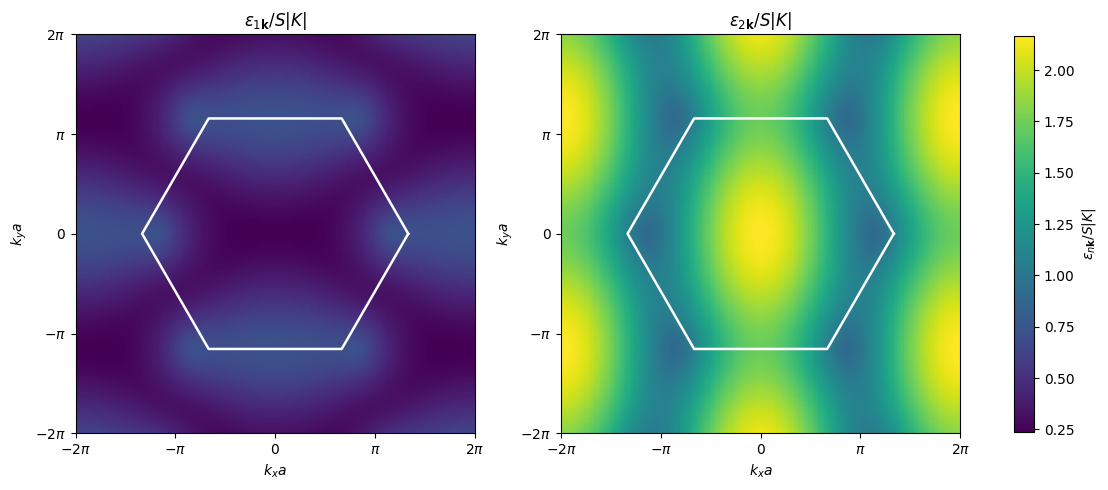

In [ ]:
sigma3 = np.diag([1, 1, -1, -1])

enk = np.zeros((len(plotkpts), 2), dtype=np.float64)
evecnk = np.zeros((len(plotkpts), 4, 2), dtype=np.complex128)
for i, k in enumerate(plotkpts):
    # vals, vecs = np.linalg.eig(sigma3 @ Dk_a(k))
    # vals = np.real_if_close(vals, tol=1000)
    # vals_real = np.real(vals)

    # eigpos_idx = np.where(vals_real > 1e-10)[0]
    # if eigpos_idx.size != 2:
    #     raise RuntimeError(f"Expected 2 positive magnon modes at k={k}, got {vals_real[eigpos_idx]}")

    # order = np.argsort(vals_real[eigpos_idx])
    # sel = eigpos_idx[order]
    # final_vals,final_vecs = vals_real[sel],vecs[:,sel]

    eigenvalues,eigenvectors = getDkEigs(Dk_a,k)

    enk[i] = eigenvalues
    evecnk[i] = eigenvectors

en1 = enk[:, 0].reshape(Nky, Nkx)
en2 = enk[:, 1].reshape(Nky, Nkx)
ev1 = evecnk[:, :, 0].reshape(Nky, Nkx, 4)
ev2 = evecnk[:, :, 1].reshape(Nky, Nkx, 4)

# First-BZ hexagon from reciprocal primitive vectors B1=2π b1, B2=2π b2
B1 = 2 * np.pi * b1
B2 = 2 * np.pi * b2
hex_vertices = np.array([
    (2 * B1 + B2) / 3,
    (B1 + 2 * B2) / 3,
    (-B1 + B2) / 3,
    -(2 * B1 + B2) / 3,
    -(B1 + 2 * B2) / 3,
    (B1 - B2) / 3,
])
hex_plot = np.vstack([hex_vertices, hex_vertices[0]]) * a  # axes are k_x a, k_y a

vmin = min(np.min(en1), np.min(en2))
vmax = max(np.max(en1), np.max(en2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)
im0 = axes[0].pcolormesh(KX_a, KY_a, en1, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].pcolormesh(KX_a, KY_a, en2, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)

for ax, n in zip(axes, [1, 2]):
    ax.plot(hex_plot[:, 0], hex_plot[:, 1], color='white', linewidth=1.8)
    ax.set_xlim(-2 * np.pi, 2 * np.pi)
    ax.set_ylim(-2 * np.pi, 2 * np.pi)
    ax.set_xticks(fig3_ticks, fig3_ticklabels)
    ax.set_yticks(fig3_ticks, fig3_ticklabels)
    ax.set_xlabel(r'$k_x a$')
    ax.set_ylabel(r'$k_y a$')
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(rf'$\epsilon_{{{n}\mathbf{{k}}}}/S|K|$')

cbar = fig.colorbar(im0, ax=axes, shrink=0.92)
cbar.set_label(r'$\epsilon_{n\mathbf{k}}/S|K|$')
plt.show()

# Step 4: Compute Berry Curvature

# Step 5: Compute Hall Conductivity (Sum Berry Curvature over BZ)